# Test 1: Quantum ON vs OFF (Same Checkpoint)

The most direct test. Evaluate the trained model with `enable_quantum=True` vs `False`.
Also sweep quantum_scale from 0 to 2.0 to find optimal contribution.

**Key question:** Does the quantum branch improve predictions?

In [1]:
from setup_helpers import *

ckpt = load_checkpoint()
model, model_cfg, device = build_trained_model(ckpt)
data = load_data()
print("Model and data loaded.")

Model and data loaded.


## 1.1 — Quantum ON vs OFF on Validation and Holdout

In [2]:
results = {}

for split_name, split in [("val", data.val), ("holdout", data.holdout)]:
    results[f"{split_name}_q_off"] = evaluate(model, split, data.target_scaler, enable_quantum=False)
    results[f"{split_name}_q_on_0.5"] = evaluate(model, split, data.target_scaler, enable_quantum=True, quantum_scale=0.5)
    results[f"{split_name}_q_on_1.0"] = evaluate(model, split, data.target_scaler, enable_quantum=True, quantum_scale=1.0)
    print(f"{split_name} done.")

val done.
holdout done.


In [3]:
# Validation comparison
val_results = {
    "Quantum OFF": results["val_q_off"],
    "Quantum ON (s=0.5)": results["val_q_on_0.5"],
    "Quantum ON (s=1.0)": results["val_q_on_1.0"],
}
print("=== Validation Set ===")
display(compare_table(val_results))

# Holdout comparison
holdout_results = {
    "Quantum OFF": results["holdout_q_off"],
    "Quantum ON (s=0.5)": results["holdout_q_on_0.5"],
    "Quantum ON (s=1.0)": results["holdout_q_on_1.0"],
}
print("\n=== Holdout Set ===")
display(compare_table(holdout_results))

=== Validation Set ===


,mRMSE,mMAE,RMSE H₂O,RMSE CO₂,RMSE CO,RMSE CH₄,RMSE NH₃
Condition,,,,,,,
Quantum OFF,0.2993,0.1831,0.4000,0.2451,0.2235,0.2344,0.3933
Quantum ON (s=0.5),0.2922,0.1787,0.3893,0.2326,0.2205,0.2325,0.3863
Quantum ON (s=1.0),0.2948,0.1825,0.4028,0.2261,0.2209,0.2334,0.3909



=== Holdout Set ===


,mRMSE,mMAE,RMSE H₂O,RMSE CO₂,RMSE CO,RMSE CH₄,RMSE NH₃
Condition,,,,,,,
Quantum OFF,0.3024,0.1834,0.4030,0.2433,0.2324,0.2350,0.3983
Quantum ON (s=0.5),0.2956,0.1792,0.3909,0.2329,0.2297,0.2342,0.3901
Quantum ON (s=1.0),0.2987,0.1837,0.4052,0.2290,0.2303,0.2362,0.3928


In [4]:
# Delta table (negative = quantum helps)
for split_name in ["val", "holdout"]:
    off = results[f"{split_name}_q_off"]
    on05 = results[f"{split_name}_q_on_0.5"]
    delta_mrmse = on05["rmse_mean"] - off["rmse_mean"]
    delta_pct = delta_mrmse / off["rmse_mean"] * 100
    print(f"\n{split_name}: mRMSE delta (ON-OFF) = {delta_mrmse:+.4f} ({delta_pct:+.2f}%)")
    for i, name in enumerate(TARGET_NAMES):
        d = on05["rmse_orig"][i] - off["rmse_orig"][i]
        print(f"  {name}: {d:+.4f}")


val: mRMSE delta (ON-OFF) = -0.0070 (-2.35%)
  H₂O: -0.0108
  CO₂: -0.0125
  CO: -0.0030
  CH₄: -0.0019
  NH₃: -0.0070

holdout: mRMSE delta (ON-OFF) = -0.0069 (-2.27%)
  H₂O: -0.0121
  CO₂: -0.0104
  CO: -0.0027
  CH₄: -0.0008
  NH₃: -0.0082


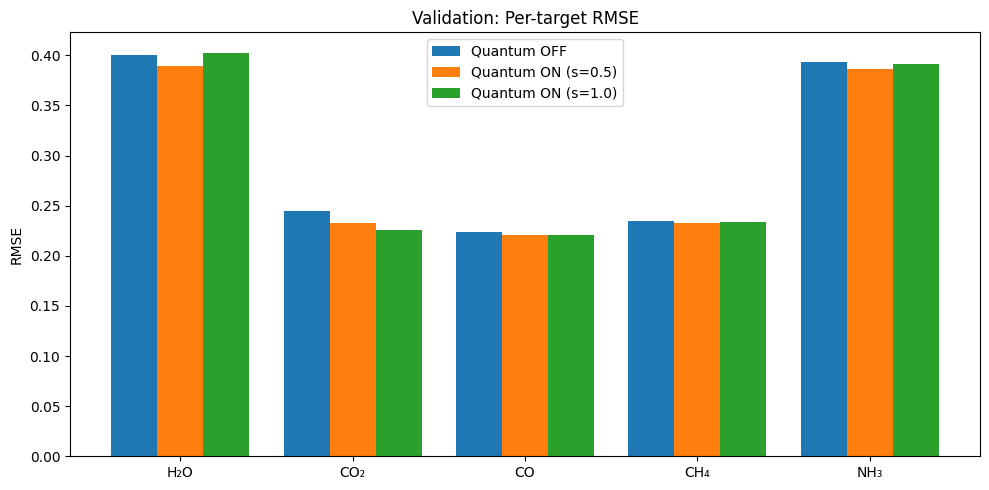

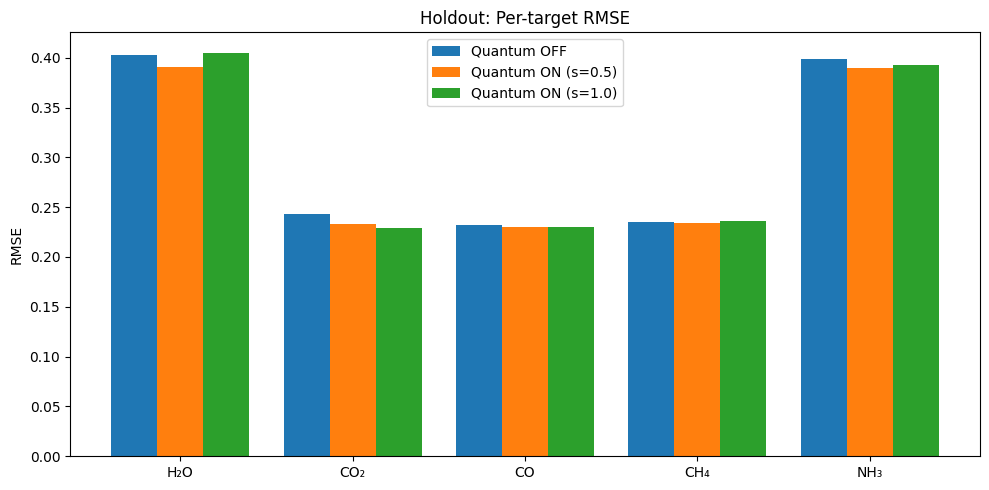

In [5]:
fig = plot_per_target(val_results, "Validation: Per-target RMSE")
plt.show()

fig = plot_per_target(holdout_results, "Holdout: Per-target RMSE")
plt.show()

## 1.2 — Quantum Scale Sweep

Since `output = classical + scale * gate * quantum_correction`, we can compute predictions at any scale via linear interpolation:

`pred(s) = pred(0) + s * (pred(1) - pred(0))`

This is valid because quantum_scale is a simple multiplier. Only need two forward passes.

In [6]:
# Scale sweep via linear interpolation (fast — only 2 forward passes needed)
scales = np.arange(0.0, 2.05, 0.05)

sweep_results = {}
for split_name, split in [("val", data.val), ("holdout", data.holdout)]:
    # Get predictions at scale=0 and scale=1
    m0 = evaluate(model, split, data.target_scaler, enable_quantum=True, quantum_scale=0.0)
    m1 = evaluate(model, split, data.target_scaler, enable_quantum=True, quantum_scale=1.0)
    pred_0 = m0["pred_orig"]
    pred_1 = m1["pred_orig"]
    true = m0["true_orig"]

    mrmses = []
    per_target_rmses = []
    for s in scales:
        pred_s = pred_0 + s * (pred_1 - pred_0)
        rmse_per_target = np.sqrt(np.mean((pred_s - true) ** 2, axis=0))
        mrmses.append(rmse_per_target.mean())
        per_target_rmses.append(rmse_per_target)

    sweep_results[split_name] = {
        "scales": scales,
        "mrmses": np.array(mrmses),
        "per_target_rmses": np.array(per_target_rmses),
    }

    best_idx = np.argmin(mrmses)
    print(f"{split_name}: optimal scale = {scales[best_idx]:.2f}, mRMSE = {mrmses[best_idx]:.4f}")
    print(f"  scale=0.0: {mrmses[0]:.4f}, scale=0.5: {mrmses[int(0.5/0.05)]:.4f}, scale=1.0: {mrmses[int(1.0/0.05)]:.4f}")

val: optimal scale = 0.60, mRMSE = 0.2920
  scale=0.0: 0.2993, scale=0.5: 0.2922, scale=1.0: 0.2948
holdout: optimal scale = 0.60, mRMSE = 0.2954
  scale=0.0: 0.3024, scale=0.5: 0.2956, scale=1.0: 0.2987


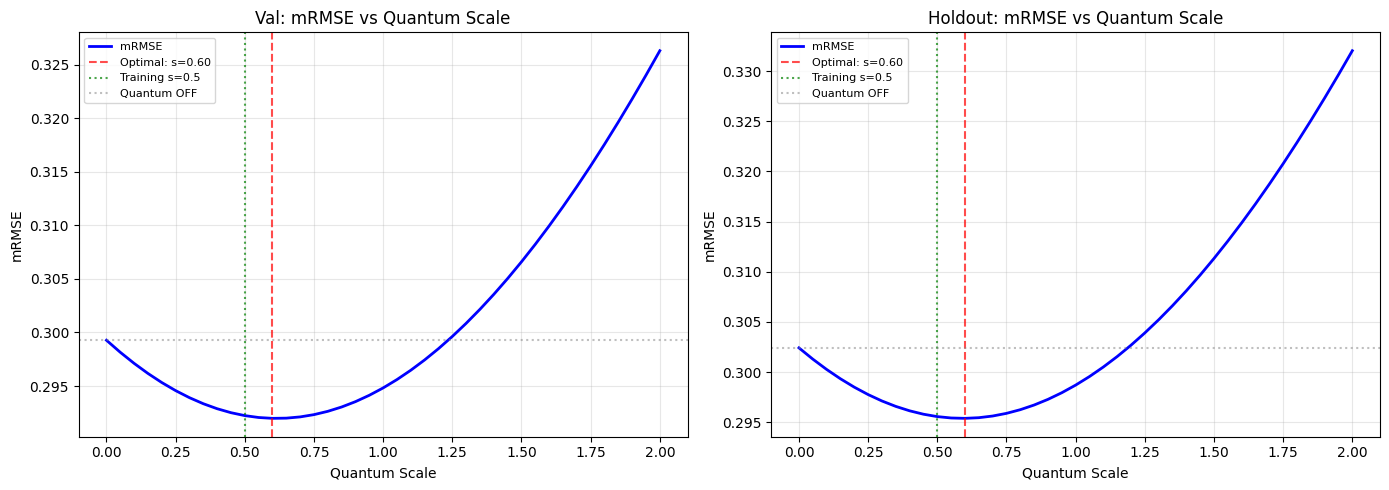

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, split_name in zip(axes, ["val", "holdout"]):
    sr = sweep_results[split_name]
    ax.plot(sr["scales"], sr["mrmses"], "b-", linewidth=2, label="mRMSE")
    best_idx = np.argmin(sr["mrmses"])
    ax.axvline(sr["scales"][best_idx], color="red", linestyle="--", alpha=0.7,
               label=f"Optimal: s={sr['scales'][best_idx]:.2f}")
    ax.axvline(0.5, color="green", linestyle=":", alpha=0.7, label="Training s=0.5")
    ax.axhline(sr["mrmses"][0], color="gray", linestyle=":", alpha=0.5, label="Quantum OFF")
    ax.set_xlabel("Quantum Scale")
    ax.set_ylabel("mRMSE")
    ax.set_title(f"{split_name.title()}: mRMSE vs Quantum Scale")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

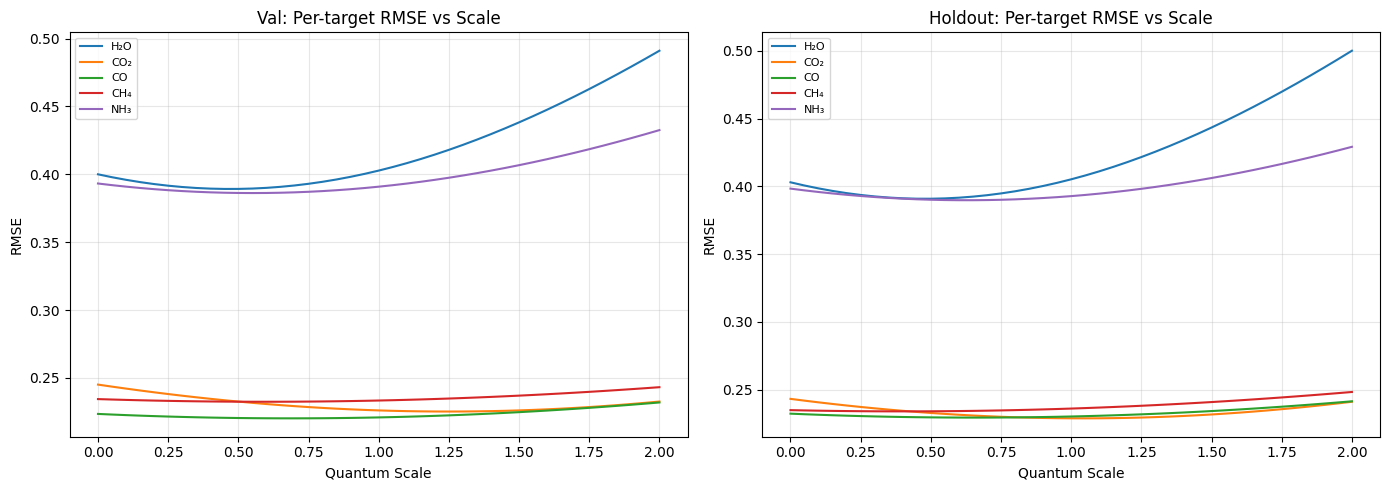

In [8]:
# Per-target scale sweep
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, split_name in zip(axes, ["val", "holdout"]):
    sr = sweep_results[split_name]
    for i, name in enumerate(TARGET_NAMES):
        ax.plot(sr["scales"], sr["per_target_rmses"][:, i], label=name)
    ax.set_xlabel("Quantum Scale")
    ax.set_ylabel("RMSE")
    ax.set_title(f"{split_name.title()}: Per-target RMSE vs Scale")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

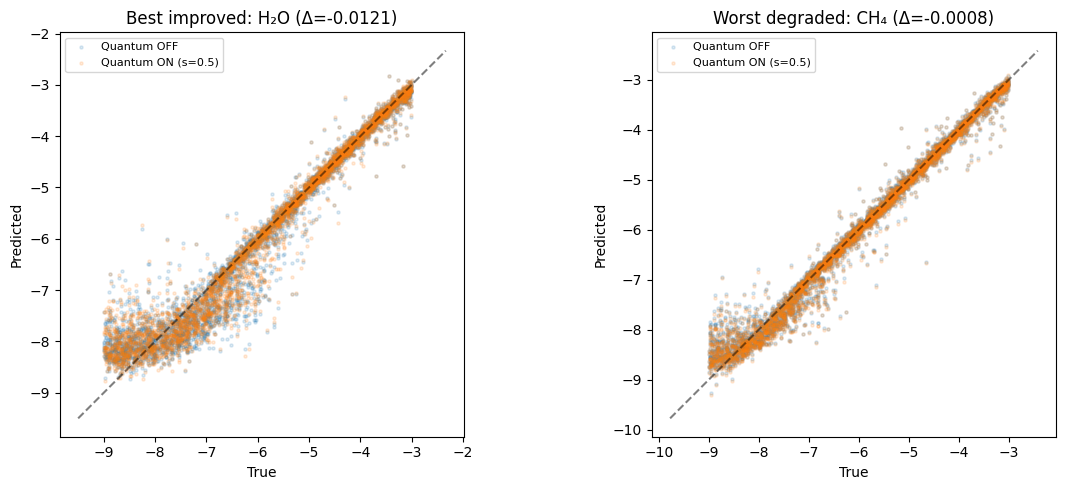

In [9]:
# Scatter: predicted vs true for holdout, quantum ON vs OFF (best and worst target)
pred_on = results["holdout_q_on_0.5"]["pred_orig"]
pred_off = results["holdout_q_off"]["pred_orig"]
true = results["holdout_q_off"]["true_orig"]

# Find best and worst target by delta RMSE
deltas = results["holdout_q_on_0.5"]["rmse_orig"] - results["holdout_q_off"]["rmse_orig"]
best_target = int(np.argmin(deltas))  # most improved
worst_target = int(np.argmax(deltas))  # most degraded

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, tidx, label in zip(axes, [best_target, worst_target], ["Best improved", "Worst degraded"]):
    ax.scatter(true[:, tidx], pred_off[:, tidx], alpha=0.15, s=5, label="Quantum OFF")
    ax.scatter(true[:, tidx], pred_on[:, tidx], alpha=0.15, s=5, label="Quantum ON (s=0.5)")
    lims = [min(true[:, tidx].min(), pred_off[:, tidx].min()) - 0.5,
            max(true[:, tidx].max(), pred_off[:, tidx].max()) + 0.5]
    ax.plot(lims, lims, "k--", alpha=0.5)
    ax.set_xlabel("True")
    ax.set_ylabel("Predicted")
    ax.set_title(f"{label}: {TARGET_NAMES[tidx]} (\u0394={deltas[tidx]:+.4f})")
    ax.legend(fontsize=8)
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

In [10]:
# Save results for other notebooks
import pickle
with open("outputs/test1_results.pkl", "wb") as f:
    pickle.dump(results, f)
with open("outputs/test1_sweep.pkl", "wb") as f:
    pickle.dump(sweep_results, f)
print("Results saved.")

Results saved.
